# NASA IMS Bearing Dataset - ML Training for RUL Prediction

This notebook trains **Machine Learning Regression Models** to predict **Remaining Useful Life (RUL)** of bearings.

## Dataset Overview: NASA IMS Bearing Dataset

| Property | Value |
|----------|-------|
| **Source** | Intelligent Maintenance Systems (IMS) Center, University of Cincinnati |
| **Type** | Run-to-failure bearing vibration data |
| **Bearings** | 4 bearings per test |
| **Sampling Rate** | 20 kHz |
| **Samples per File** | 20,480 (≈1 second) |
| **Tests** | 3 separate run-to-failure tests |

## Key Difference: Classification vs Regression

| Aspect | CWRU (Previous) | NASA (This Notebook) |
|--------|-----------------|----------------------|
| **Task** | Classification | **Regression** |
| **Output** | Fault Type (Normal/Inner/Ball/Outer) | **RUL (Remaining Useful Life)** |
| **Labels** | Discrete classes (0, 1, 2, 3) | **Continuous values (0-100%)** |
| **Models** | Classifiers (RF, SVM, GB) | **Regressors (RF, GB, SVR)** |
| **Metrics** | Accuracy, Precision, Recall | **RMSE, MAE, R²** |

## What is RUL?

**Remaining Useful Life (RUL)** = Number of operational cycles/time remaining before failure

- **RUL = 100%**: Brand new bearing (start of test)
- **RUL = 50%**: Halfway through operational life
- **RUL = 0%**: Failure imminent/occurred


In [48]:
# ============================================
# IMPORTS AND SETUP
# ============================================
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm  # Progress bar

# Scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Auto-reload modules
%load_ext autoreload
%autoreload 2

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))

# Import custom modules
from src.data.loaders import NASALoader
from src.features.signal_processing import extract_time_features, compute_fft

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"Python Version: {sys.version}")
print("Setup complete!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Python Version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Setup complete!


## 1. Data Exploration

### Understanding the Dataset Structure

The NASA IMS dataset contains:
- **Multiple test runs** (1st_test, 2nd_test, 3rd_test)
- **Time-stamped files** (e.g., `2003.10.22.12.06.24`)
- **4 channels** per file (4 bearings monitored simultaneously)
- **Tab-separated values** with no header

### File Naming Convention:
Format: `YYYY.MM.DD.HH.MM.SS`
- Files are chronologically ordered
- Time between files ≈ 5-10 minutes
- Last files indicate bearing failure


In [49]:
# ============================================
# EXPLORE DATASET STRUCTURE - ALL 3 TESTS
# ============================================

# Path to NASA data
NASA_DATA_DIR = r'../NASA_Data'

# Define all 3 test directories
test_configs = {
    '1st_test': os.path.join(NASA_DATA_DIR, '1st_test', '1st_test'),
    '2nd_test': os.path.join(NASA_DATA_DIR, '2nd_test', '2nd_test'),
    '3rd_test': os.path.join(NASA_DATA_DIR, '3rd_test', '4th_test', 'txt')  # Note: Different structure
}

# Collect information about each test
test_info = {}

print("Scanning NASA Bearing Test Directories...")
print("=" * 60)

for test_name, test_path in test_configs.items():
    if os.path.exists(test_path):
        # Get all files in directory
        files = sorted([f for f in os.listdir(test_path) 
                       if os.path.isfile(os.path.join(test_path, f))])
        
        test_info[test_name] = {
            'path': test_path,
            'files': files,
            'count': len(files)
        }
        
        print(f"\n{test_name}:")
        print(f"  Path: {test_path}")
        print(f"  Files: {len(files):,}")
        print(f"  First file: {files[0] if files else 'N/A'}")
        print(f"  Last file: {files[-1] if files else 'N/A'}")
    else:
        print(f"\n{test_name}: ✗ Path not found")
        print(f"  Expected: {test_path}")

# Calculate totals
total_files = sum(info['count'] for info in test_info.values())

print("\n" + "=" * 60)
print(f"TOTAL FILES ACROSS ALL TESTS: {total_files:,}")
print("=" * 60)

# We'll combine all tests for training
print("\nStrategy: Combine all 3 tests into one large dataset")
print("  - More data = better model generalization")
print("  - Captures different failure modes")
print("  - Train/Val/Test split: 60/20/20 (temporal within each test)")


Scanning NASA Bearing Test Directories...



1st_test:
  Path: ../NASA_Data\1st_test\1st_test
  Files: 2,156
  First file: 2003.10.22.12.06.24
  Last file: 2003.11.25.23.39.56

2nd_test:
  Path: ../NASA_Data\2nd_test\2nd_test
  Files: 984
  First file: 2004.02.12.10.32.39
  Last file: 2004.02.19.06.22.39

3rd_test:
  Path: ../NASA_Data\3rd_test\4th_test\txt
  Files: 6,324
  First file: 2004.03.04.09.27.46
  Last file: 2004.04.18.02.42.55

TOTAL FILES ACROSS ALL TESTS: 9,464

Strategy: Combine all 3 tests into one large dataset
  - More data = better model generalization
  - Captures different failure modes
  - Train/Val/Test split: 60/20/20 (temporal within each test)


## 2. Load and Visualize Sample Data

### Data Format:
Each file contains 4 columns (one per bearing):
- **Column 0**: Bearing 1
- **Column 1**: Bearing 2  
- **Column 2**: Bearing 3
- **Column 3**: Bearing 4

Each column has 20,480 samples (1 second at 20 kHz)


Visualizing vibration signals at different time points...

File: 2003.10.22.12.06.24 - Start (Healthy)


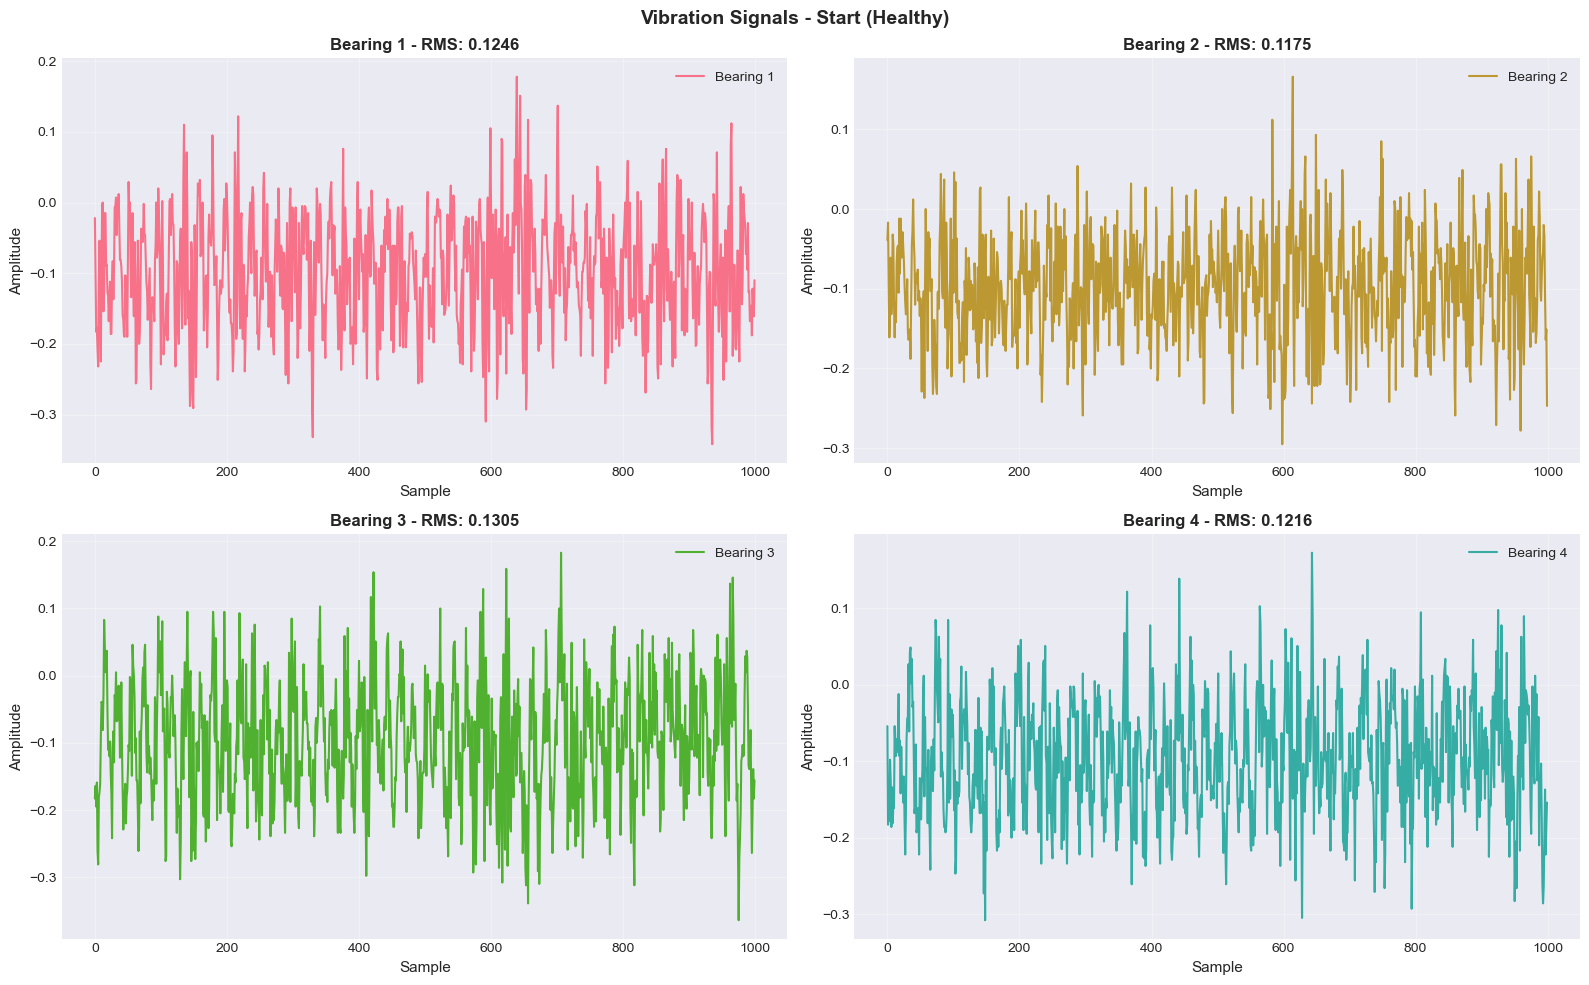


File: 2003.11.15.18.18.46 - Middle


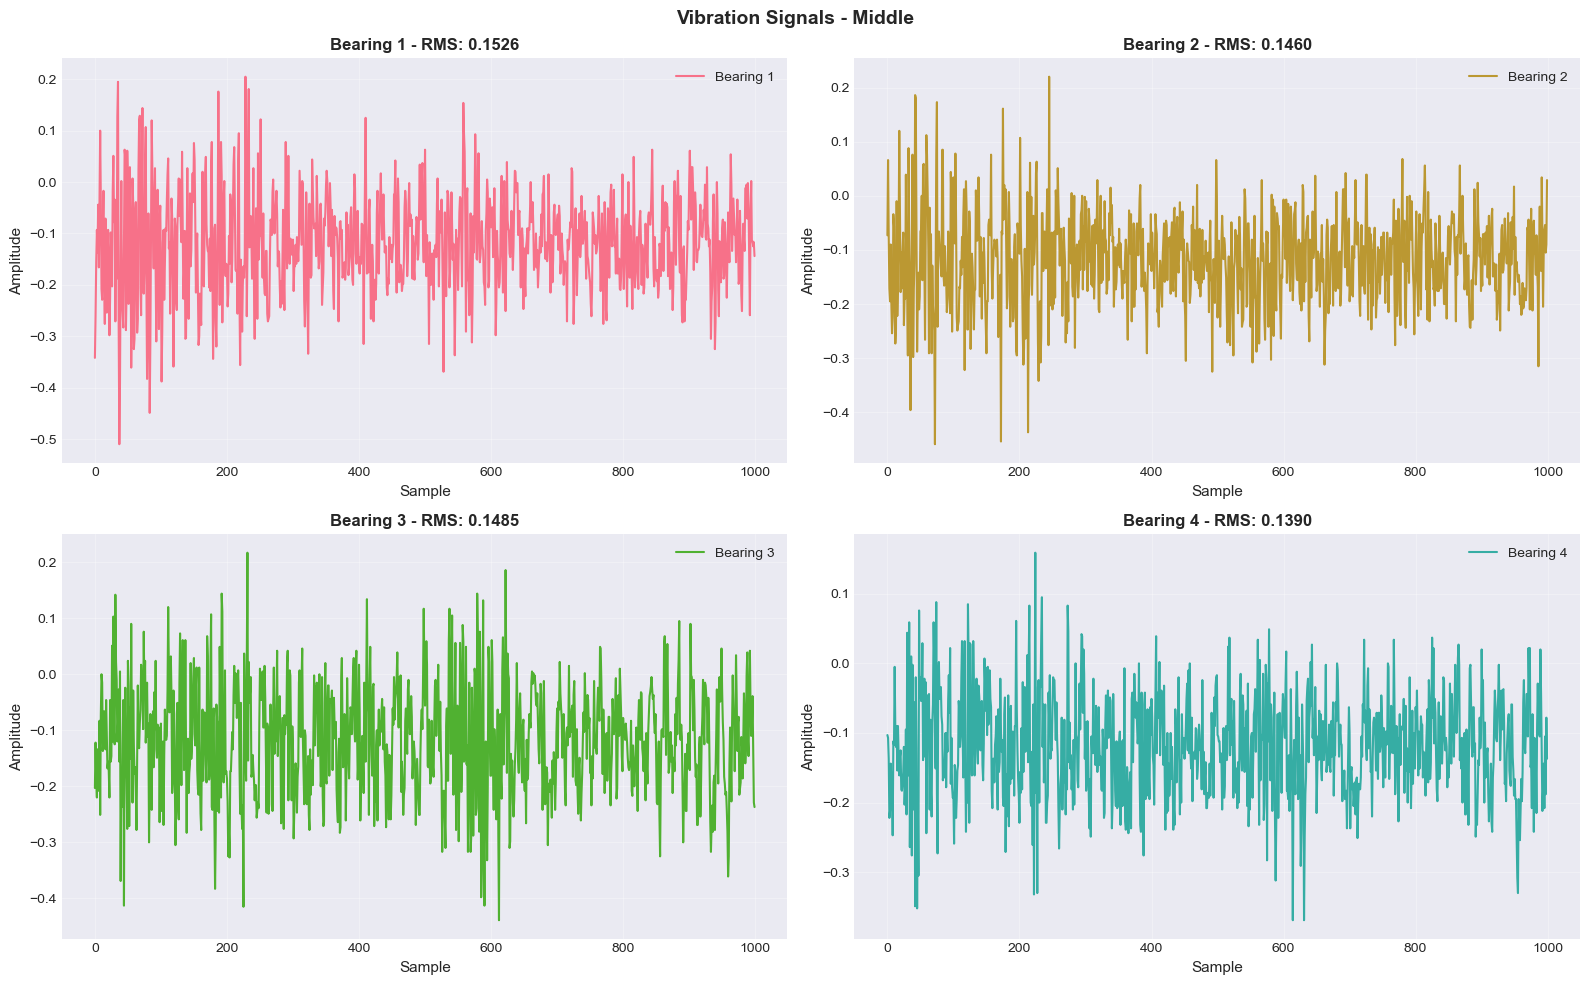


File: 2003.11.25.23.39.56 - End (Near Failure)


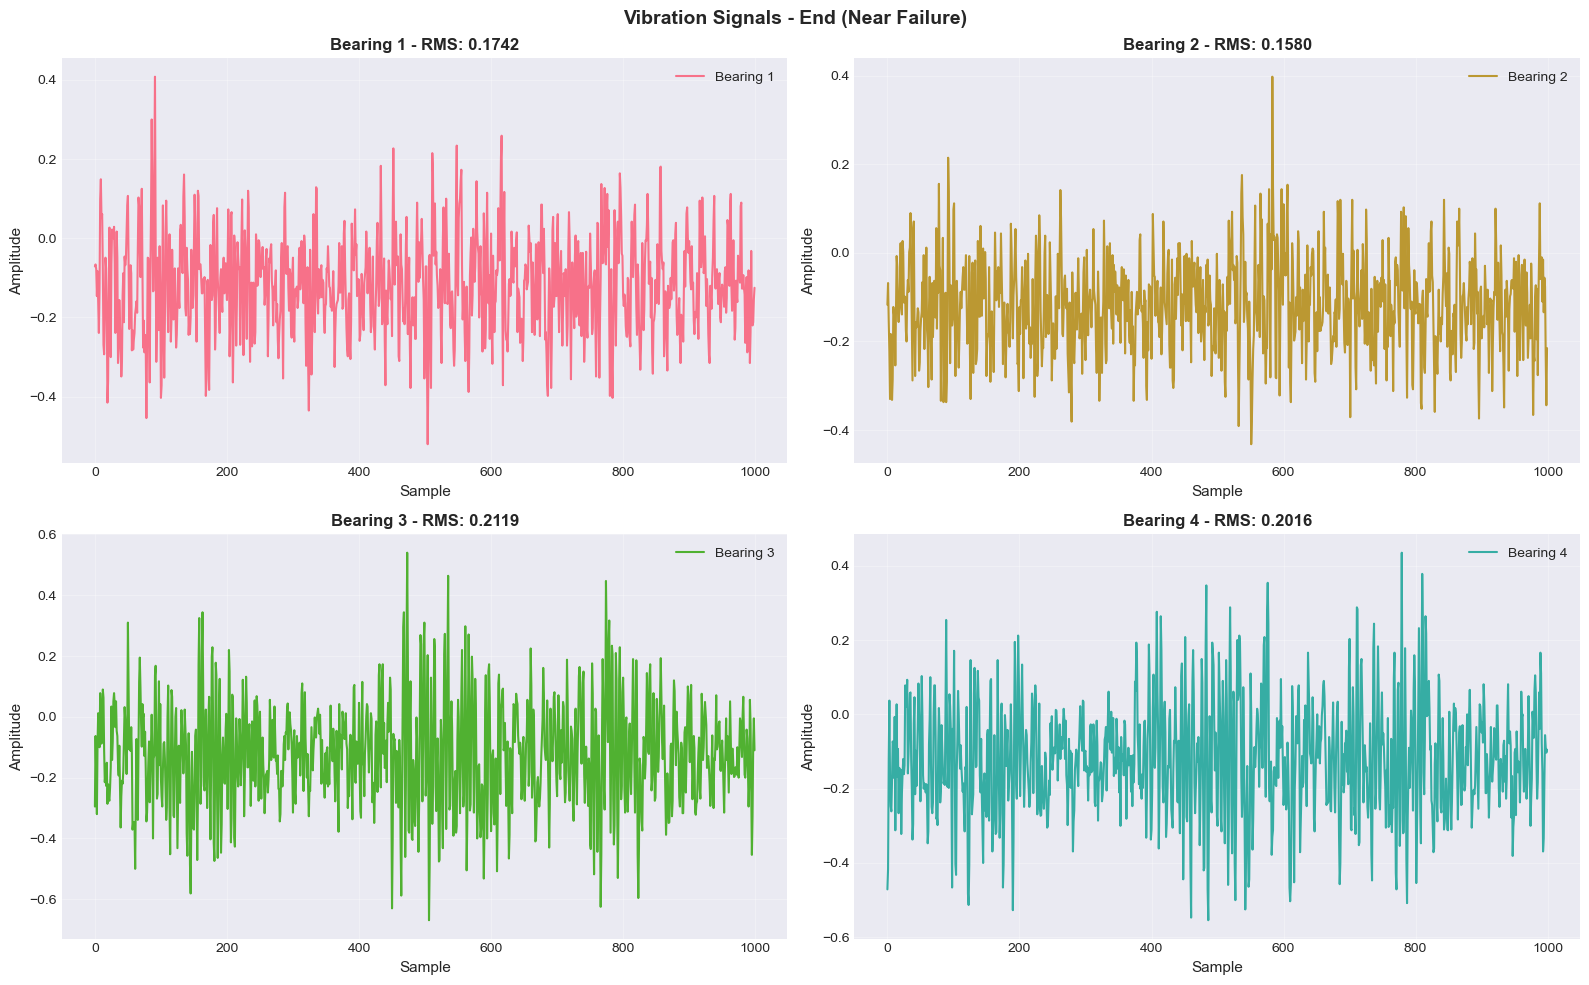



Data shape: (20480, 8)
Sampling rate: 20 kHz
Duration: 1.02 seconds


In [50]:
# Fix: Define TEST_PATH and data_files using 2nd_test (standard)
TEST_PATH = test_configs['2nd_test']
data_files = test_info['2nd_test']['files']

# ============================================
# LOAD AND VISUALIZE SAMPLE DATA
# ============================================

# Initialize NASA loader
loader = NASALoader(TEST_PATH)

# Load first, middle, and last files to see degradation
sample_indices = [0, len(data_files)//2, -1]
sample_labels = ['Start (Healthy)', 'Middle', 'End (Near Failure)']

print("Visualizing vibration signals at different time points...\n")

# Plot each time point separately
for idx, label in zip(sample_indices, sample_labels):
    filename = data_files[idx]
    data = loader.load_snapshot(filename)  # Shape: (20480, 4)
    
    print(f"File: {filename} - {label}")
    
    # Create separate figure for this time point
    plt.figure(figsize=(16, 10))
    
    for bearing in range(4):
        signal = data[:, bearing]
        
        # Create subplot for each bearing
        plt.subplot(2, 2, bearing + 1)
        plt.plot(signal[:1000], linewidth=1.5, color=f'C{bearing}', label=f'Bearing {bearing+1}')
        
        # Calculate RMS for annotation
        rms = np.sqrt(np.mean(signal**2))
        
        plt.title(f'Bearing {bearing+1} - RMS: {rms:.4f}', fontsize=12, fontweight='bold')
        plt.xlabel('Sample', fontsize=11)
        plt.ylabel('Amplitude', fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.legend(loc='upper right', fontsize=10)
    
    plt.suptitle(f'Vibration Signals - {label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

print(f"\nData shape: {data.shape}")
print(f"Sampling rate: 20 kHz")
print(f"Duration: {data.shape[0]/20000:.2f} seconds")


## 3. RUL Label Creation

### RUL Calculation Strategy:

Since we have run-to-failure data, we can calculate RUL as:

```
RUL = (Total Files - Current File Index) / Total Files * 100%
```

### Example:
- Total files: 2156
- File 0 (start): RUL = (2156 - 0) / 2156 = 100%
- File 1078 (middle): RUL = (2156 - 1078) / 2156 = 50%
- File 2155 (end): RUL = (2156 - 2155) / 2156 ≈ 0%

### Assumptions:
- **Linear degradation**: RUL decreases linearly over time
- **All bearings degrade**: We'll analyze each bearing separately
- **Last file = failure**: RUL = 0 at the last measurement


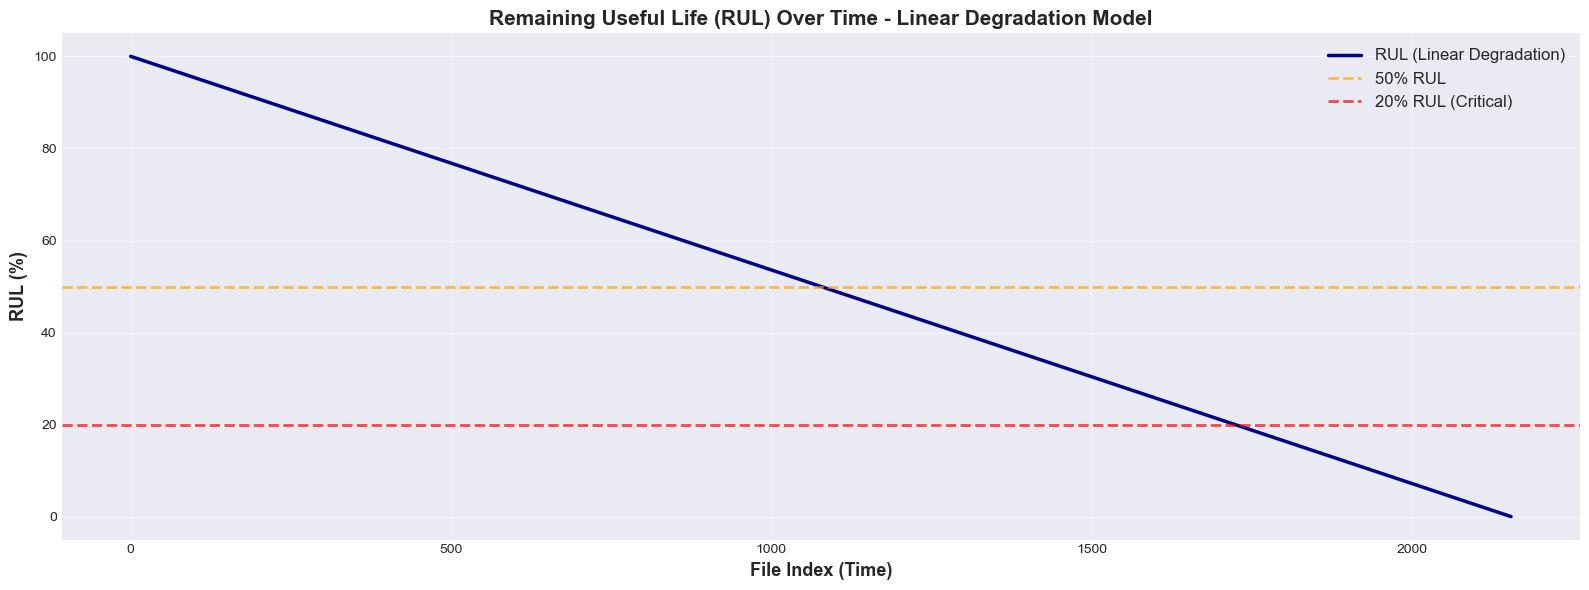

RUL Statistics:
  Min RUL: 0.05%
  Max RUL: 100.00%
  Mean RUL: 50.02%

Example RUL values:
  File    0: RUL = 100.00%
  File  539: RUL =  75.00%
  File 1078: RUL =  50.00%
  File 1617: RUL =  25.00%
  File 2155: RUL =   0.05%


In [51]:
# ============================================
# CREATE RUL LABELS (Percentage + Time Units)
# ============================================

# NASA test sampling information
SAMPLING_INTERVAL_MINUTES = 10  # Files recorded every 10 minutes
MINUTES_PER_HOUR = 60
HOURS_PER_DAY = 24
DAYS_PER_WEEK = 7
DAYS_PER_MONTH = 30  # Approximate
DAYS_PER_YEAR = 365

def calculate_rul(file_index, total_files):
    """
    Calculate Remaining Useful Life (RUL) in multiple formats.
    
    Args:
        file_index: Current file index (0 to total_files-1)
        total_files: Total number of files in the test
    
    Returns:
        Dictionary with RUL in different units
    """
    # Calculate remaining files
    remaining_files = total_files - file_index
    
    # RUL as percentage
    rul_percentage = (remaining_files / total_files) * 100
    
    # RUL in time units
    rul_minutes = remaining_files * SAMPLING_INTERVAL_MINUTES
    rul_hours = rul_minutes / MINUTES_PER_HOUR
    rul_days = rul_hours / HOURS_PER_DAY
    rul_weeks = rul_days / DAYS_PER_WEEK
    rul_months = rul_days / DAYS_PER_MONTH
    rul_years = rul_days / DAYS_PER_YEAR
    
    return {
        'percentage': rul_percentage,
        'minutes': rul_minutes,
        'hours': rul_hours,
        'days': rul_days,
        'weeks': rul_weeks,
        'months': rul_months,
        'years': rul_years
    }

def format_rul_time(rul_dict):
    """
    Format RUL in the most appropriate time unit.
    """
    if rul_dict['years'] >= 1:
        return f"{rul_dict['years']:.2f} years"
    elif rul_dict['months'] >= 1:
        return f"{rul_dict['months']:.2f} months"
    elif rul_dict['weeks'] >= 1:
        return f"{rul_dict['weeks']:.2f} weeks"
    elif rul_dict['days'] >= 1:
        return f"{rul_dict['days']:.2f} days"
    elif rul_dict['hours'] >= 1:
        return f"{rul_dict['hours']:.2f} hours"
    else:
        return f"{rul_dict['minutes']:.0f} minutes"

# Example: Calculate RUL for different points
print("RUL Calculation Examples:")
print("=" * 80)

example_total_files = 2156  # 1st test
example_points = [0, 500, 1000, 1500, 2000, 2155]

for file_idx in example_points:
    rul = calculate_rul(file_idx, example_total_files)
    print(f"\nFile {file_idx:4d}:")
    print(f"  RUL: {rul['percentage']:6.2f}%")
    print(f"  Time remaining:")
    print(f"    {rul['minutes']:8.0f} minutes")
    print(f"    {rul['hours']:8.2f} hours")
    print(f"    {rul['days']:8.2f} days")
    print(f"    {rul['weeks']:8.2f} weeks")
    print(f"    {rul['months']:8.2f} months")
    print(f"    {rul['years']:8.2f} years")
    print(f"  Best format: {format_rul_time(rul)}")

print("\n" + "=" * 80)
print("\nNote: Files are recorded every 10 minutes in NASA dataset")
print("Total test duration ≈ 2156 files × 10 min = 21,560 min ≈ 15 days")


## RUL Visualization in Multiple Time Units

Let's visualize RUL in different time formats to see which is most intuitive:
- **Percentage**: 0-100%
- **Hours**: Useful for short-term predictions
- **Days**: Most practical for maintenance planning
- **Weeks**: Good for medium-term planning
- **Months**: Long-term planning
- **Years**: Very long-term planning


In [ ]:
# ============================================
# VISUALIZE RUL IN MULTIPLE TIME UNITS
# ============================================

# Calculate RUL in all formats for 1st test (example)
example_files = 2156
rul_data = [calculate_rul(i, example_files) for i in range(example_files)]

# Extract different time units
rul_percentage = [r['percentage'] for r in rul_data]
rul_hours = [r['hours'] for r in rul_data]
rul_days = [r['days'] for r in rul_data]
rul_weeks = [r['weeks'] for r in rul_data]
rul_months = [r['months'] for r in rul_data]
rul_years = [r['years'] for r in rul_data]

# Create separate plots for each unit
time_indices = np.arange(len(rul_data))

# 1. RUL in Percentage
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_percentage, linewidth=2.5, color='darkblue', label='RUL (%)')
plt.axhline(y=50, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='50% RUL')
plt.axhline(y=20, color='red', linestyle='--', linewidth=2, alpha=0.7, label='20% RUL (Critical)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (%)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Percentage', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 2. RUL in Hours
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_hours, linewidth=2.5, color='green', label='RUL (Hours)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (Hours)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Hours', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 3. RUL in Days
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_days, linewidth=2.5, color='purple', label='RUL (Days)')
plt.axhline(y=7, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='1 Week')
plt.axhline(y=3, color='red', linestyle='--', linewidth=2, alpha=0.7, label='3 Days (Critical)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (Days)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Days', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 4. RUL in Weeks
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_weeks, linewidth=2.5, color='coral', label='RUL (Weeks)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (Weeks)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Weeks', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 5. RUL in Months
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_months, linewidth=2.5, color='teal', label='RUL (Months)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (Months)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Months', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 6. RUL in Years
plt.figure(figsize=(16, 5))
plt.plot(time_indices, rul_years, linewidth=2.5, color='brown', label='RUL (Years)')
plt.xlabel('File Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (Years)', fontsize=13, fontweight='bold')
plt.title('Remaining Useful Life - Years', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nRUL Statistics for Full Test Duration:")
print("=" * 60)
print(f"Total duration: {rul_days[0]:.1f} days = {rul_weeks[0]:.2f} weeks = {rul_months[0]:.2f} months")


## 4. Feature Extraction

### Feature Categories:

We'll extract multiple types of features from each bearing signal:

#### Time-Domain Features:
- **RMS** (Root Mean Square): Overall vibration level
- **Mean**: Average amplitude
- **Std**: Signal variability
- **Kurtosis**: Impulsiveness (high for bearing faults)
- **Skewness**: Asymmetry
- **Peak-to-Peak**: Maximum range
- **Crest Factor**: Peak/RMS ratio

#### Frequency-Domain Features:
- **Spectral Centroid**: Center of mass of spectrum
- **Spectral Spread**: Spread around centroid
- **Spectral Entropy**: Randomness in frequency domain

### Why These Features?
- Bearing degradation causes changes in vibration patterns
- Kurtosis increases as faults develop (impacts/spikes)
- RMS increases as wear progresses
- Frequency features capture changes in resonances


In [52]:
# ============================================
# FEATURE EXTRACTION
# ============================================

def extract_features_from_signal(signal):
    """
    Extract comprehensive features from a vibration signal.
    
    Args:
        signal: 1D numpy array of vibration data
    
    Returns:
        Dictionary of features
    """
    features = {}
    
    # Time-domain features
    features['rms'] = np.sqrt(np.mean(signal**2))
    features['mean'] = np.mean(signal)
    features['std'] = np.std(signal)
    features['max'] = np.max(signal)
    features['min'] = np.min(signal)
    features['peak_to_peak'] = features['max'] - features['min']
    features['crest_factor'] = features['max'] / (features['rms'] + 1e-10)
    
    # Statistical moments
    features['kurtosis'] = np.mean((signal - features['mean'])**4) / (features['std']**4 + 1e-10)
    features['skewness'] = np.mean((signal - features['mean'])**3) / (features['std']**3 + 1e-10)
    
    # Frequency-domain features
    fft_vals = np.abs(np.fft.fft(signal))
    fft_vals = fft_vals[:len(fft_vals)//2]  # Take positive frequencies
    freqs = np.fft.fftfreq(len(signal), 1/20000)[:len(fft_vals)]
    
    # Spectral centroid
    features['spectral_centroid'] = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-10)
    
    # Spectral spread
    features['spectral_spread'] = np.sqrt(np.sum(((freqs - features['spectral_centroid'])**2) * fft_vals) / 
                                          (np.sum(fft_vals) + 1e-10))
    
    # Spectral entropy
    psd = fft_vals**2
    psd_norm = psd / (np.sum(psd) + 1e-10)
    features['spectral_entropy'] = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
    
    return features

print("Feature extraction function defined.")
print("\nFeature list:")
sample_signal = np.random.randn(1000)
sample_features = extract_features_from_signal(sample_signal)
for i, feat_name in enumerate(sample_features.keys(), 1):
    print(f"  {i:2d}. {feat_name}")
print(f"\nTotal features per bearing: {len(sample_features)}")
print(f"Total features (4 bearings): {len(sample_features) * 4}")


Feature extraction function defined.

Feature list:
   1. rms
   2. mean
   3. std
   4. max
   5. min
   6. peak_to_peak
   7. crest_factor
   8. kurtosis
   9. skewness
  10. spectral_centroid
  11. spectral_spread
  12. spectral_entropy

Total features per bearing: 12
Total features (4 bearings): 48


## 5. Extract Features from All Files

### Processing Strategy:

For each file:
1. Load 4-channel vibration data
2. Extract features from each bearing (channel)
3. Combine features from all 4 bearings
4. Associate with RUL label

### Note on Processing Time:
- Processing 2000+ files takes time
- We'll use a progress bar to monitor
- Consider using a subset for initial testing


In [53]:
# ============================================
# EXTRACT FEATURES FROM ALL 3 TESTS
# ============================================

# Option to use subset for faster testing
USE_SUBSET = False  # Set to True for quick testing
SUBSET_SIZE_PER_TEST = 300  # Files per test if using subset

# Initialize storage for all data
all_features = []
all_rul = []
all_test_labels = []  # Track which test each sample came from

print("Extracting features from all 3 NASA bearing tests...")
print("=" * 70)

# Process each test
for test_name in ['1st_test', '2nd_test', '3rd_test']:
    if test_name not in test_info:
        print(f"\nSkipping {test_name} - not found")
        continue
    
    print(f"\nProcessing {test_name}...")
    
    test_path = test_info[test_name]['path']
    test_files = test_info[test_name]['files']
    
    # Use subset if enabled
    if USE_SUBSET and len(test_files) > SUBSET_SIZE_PER_TEST:
        # Take evenly spaced files to capture full degradation
        indices = np.linspace(0, len(test_files)-1, SUBSET_SIZE_PER_TEST, dtype=int)
        files_to_process = [test_files[i] for i in indices]
        print(f"  Using subset: {len(files_to_process)} files (evenly spaced)")
    else:
        files_to_process = test_files
        print(f"  Processing all {len(files_to_process)} files")
    
    # Initialize loader for this test
    loader = NASALoader(test_path)
    
    # Calculate RUL for this test
    total_files_in_test = len(files_to_process)
    
    # Extract features
    test_features = []
    test_rul = []
    
    for file_idx, filename in enumerate(tqdm(files_to_process, desc=f"  {test_name}")):
        try:
            # Load data
            data = loader.load_snapshot(filename)
            
            # Calculate RUL for this file
            # Fix: Extract percentage from RUL dictionary
            rul_dict = calculate_rul(file_idx, total_files_in_test)
            rul = rul_dict['percentage']
            
            # Extract features from each bearing
            file_features = {}
            for bearing_idx in range(4):
                signal = data[:, bearing_idx]
                bearing_features = extract_features_from_signal(signal)
                
                # Add bearing prefix
                for feat_name, feat_value in bearing_features.items():
                    file_features[f'bearing{bearing_idx+1}_{feat_name}'] = feat_value
            
            test_features.append(file_features)
            test_rul.append(rul)
            
        except Exception as e:
            print(f"\n  Error processing {filename}: {e}")
            continue
    
    # Add to combined dataset
    all_features.extend(test_features)
    all_rul.extend(test_rul)
    all_test_labels.extend([test_name] * len(test_features))
    
    print(f"  ✓ Extracted {len(test_features)} samples from {test_name}")

# Convert to DataFrame
features_df = pd.DataFrame(all_features)
features_df['RUL'] = all_rul
features_df['Test'] = all_test_labels

print("\n" + "=" * 70)
print("✓ Feature extraction complete!")
print(f"\nCombined Dataset:")
print(f"  Total samples: {len(features_df):,}")
print(f"  Features: {features_df.shape[1] - 2}  (48 features + RUL + Test)")
print(f"\nSamples per test:")
for test_name in ['1st_test', '2nd_test', '3rd_test']:
    count = (features_df['Test'] == test_name).sum()
    if count > 0:
        print(f"  {test_name}: {count:,} samples")

print("\nFirst few samples:")
display(features_df.head())


Extracting features from all 3 NASA bearing tests...

Processing 1st_test...
  Processing all 2156 files


  1st_test: 100%|██████████| 2156/2156 [01:41<00:00, 21.33it/s]


  ✓ Extracted 2156 samples from 1st_test

Processing 2nd_test...
  Processing all 984 files


  2nd_test: 100%|██████████| 984/984 [00:36<00:00, 26.93it/s]


  ✓ Extracted 984 samples from 2nd_test

Processing 3rd_test...
  Processing all 6324 files


  3rd_test: 100%|██████████| 6324/6324 [03:45<00:00, 28.02it/s]


  ✓ Extracted 6324 samples from 3rd_test

✓ Feature extraction complete!

Combined Dataset:
  Total samples: 9,464
  Features: 48  (48 features + RUL + Test)

Samples per test:
  1st_test: 2,156 samples
  2nd_test: 984 samples
  3rd_test: 6,324 samples

First few samples:


,bearing1_rms,bearing1_mean,bearing1_std,bearing1_max,bearing1_min,bearing1_peak_to_peak,bearing1_crest_factor,bearing1_kurtosis,bearing1_skewness,bearing1_spectral_centroid,...,bearing4_min,bearing4_peak_to_peak,bearing4_crest_factor,bearing4_kurtosis,bearing4_skewness,bearing4_spectral_centroid,bearing4_spectral_spread,bearing4_spectral_entropy,RUL,Test
0,0.124614,-0.094593,0.081122,0.388,-0.720,1.108,3.113619,4.069153,-0.029993,4109.020485,...,-0.530,0.786,2.104534,3.292212,-0.053183,4686.870158,3057.885839,3.273248,100.000000,1st_test
1,0.123811,-0.094903,0.079515,0.388,-0.654,1.042,3.133804,4.161541,-0.070075,4114.450614,...,-0.625,0.867,1.980656,3.291636,-0.032987,4669.268650,3047.171148,3.145429,99.953618,1st_test
2,0.125246,-0.096187,0.080217,0.317,-0.623,0.940,2.531011,3.986276,-0.041646,4123.927974,...,-0.432,0.718,2.314434,3.173287,-0.028980,4684.875126,3051.497215,3.067490,99.907236,1st_test
3,0.125197,-0.095613,0.080825,0.457,-0.598,1.055,3.650234,4.034284,0.005162,4106.689128,...,-0.483,0.727,1.987774,3.319821,-0.050404,4694.087409,3060.488304,3.181347,99.860853,1st_test
4,0.125618,-0.095133,0.082034,0.388,-0.623,1.011,3.088726,4.110155,-0.060196,4088.578350,...,-0.571,0.837,2.182727,3.340814,-0.044493,4689.740546,3051.994522,3.166968,99.814471,1st_test


## 6. Train-Validation-Test Split

### Split Strategy for Time-Series Data:

**Important**: Unlike random splits, we must preserve temporal order!

```
Time →
[Early files] → [Middle files] → [Late files]
   Training         Validation        Test
    (60%)             (20%)           (20%)
```

### Why Temporal Split?
- **Random split**: Model sees future data during training (data leakage!)
- **Temporal split**: Model trained on early data, tested on later data (realistic)

### Split Ratios:
- **Training (60%)**: Early operational life (high RUL)
- **Validation (20%)**: Middle life (medium RUL)
- **Test (20%)**: Late life (low RUL) - most critical for prediction!


Dataset Split (Temporal):
  Training:   5678 samples (60.0%)
  Validation: 1893 samples (20.0%)
  Test:       1893 samples (20.0%)

RUL Distribution:
  Train - Mean RUL: 63.40%, Range: [0.0, 100.0]
  Val   - Mean RUL: 44.91%, Range: [29.9, 59.9]
  Test  - Mean RUL: 14.97%, Range: [0.0, 29.9]


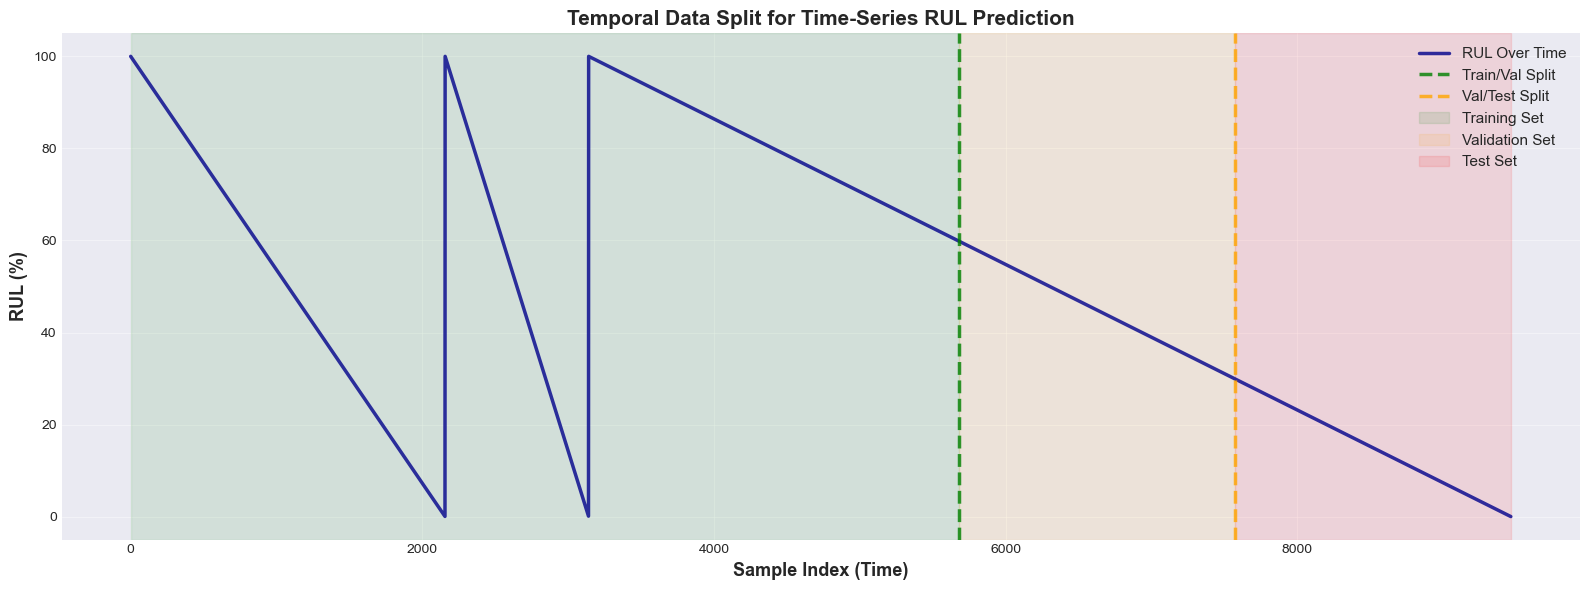

In [54]:
# ============================================
# TRAIN-VALIDATION-TEST SPLIT (TEMPORAL)
# ============================================

# Separate features and target
X = features_df.drop(['RUL', 'Test'], axis=1)  # Features (drop RUL and Test column)
y = features_df['RUL']                # Target (RUL)

# Calculate split indices (temporal order preserved)
n_samples = len(X)
train_end = int(0.6 * n_samples)
val_end = int(0.8 * n_samples)

# Split data
X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("Dataset Split (Temporal):")
print(f"  Training:   {X_train.shape[0]} samples ({X_train.shape[0]/n_samples*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]} samples ({X_val.shape[0]/n_samples*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]} samples ({X_test.shape[0]/n_samples*100:.1f}%)")

print("\nRUL Distribution:")
print(f"  Train - Mean RUL: {y_train.mean():.2f}%, Range: [{y_train.min():.1f}, {y_train.max():.1f}]")
print(f"  Val   - Mean RUL: {y_val.mean():.2f}%, Range: [{y_val.min():.1f}, {y_val.max():.1f}]")
print(f"  Test  - Mean RUL: {y_test.mean():.2f}%, Range: [{y_test.min():.1f}, {y_test.max():.1f}]")

# Visualize split
plt.figure(figsize=(16, 6))
plt.plot(y, label='RUL Over Time', linewidth=2.5, color='darkblue', alpha=0.8)
plt.axvline(x=train_end, color='green', linestyle='--', linewidth=2.5, label='Train/Val Split', alpha=0.8)
plt.axvline(x=val_end, color='orange', linestyle='--', linewidth=2.5, label='Val/Test Split', alpha=0.8)

# Add shaded regions
plt.axvspan(0, train_end, alpha=0.1, color='green', label='Training Set')
plt.axvspan(train_end, val_end, alpha=0.1, color='orange', label='Validation Set')
plt.axvspan(val_end, n_samples, alpha=0.1, color='red', label='Test Set')

plt.xlabel('Sample Index (Time)', fontsize=13, fontweight='bold')
plt.ylabel('RUL (%)', fontsize=13, fontweight='bold')
plt.title('Temporal Data Split for Time-Series RUL Prediction', fontsize=15, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## 7. Feature Scaling

### Why Scale Features?

Different features have different scales:
- RMS: 0.01 - 0.5
- Spectral Centroid: 1000 - 5000 Hz
- Kurtosis: 2 - 10

### Problems Without Scaling:
- **SVR**: Very sensitive to feature scales
- **Gradient Boosting**: Less affected but still benefits
- **Random Forest**: Not affected (tree-based)

### StandardScaler:
Transforms features to have:
- Mean = 0
- Standard Deviation = 1

**Important**: Fit scaler on training data only, then transform all sets!


In [55]:
# ============================================
# FEATURE SCALING
# ============================================

# Initialize scaler
scaler = StandardScaler()

# Fit on training data ONLY (to avoid data leakage)
scaler.fit(X_train)

# Transform all sets using the same scaler
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Complete!")
print(f"\nScaled Training Data:")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f} (should be ≈0)")
print(f"  Std:  {X_train_scaled.std(axis=0).mean():.6f} (should be ≈1)")

# Visualize scaling effect on first feature
feature_idx = 0
feature_name = features_df.columns[feature_idx]

# Before scaling
plt.figure(figsize=(14, 6))
plt.hist(X_train.iloc[:, feature_idx], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.title(f'Before Scaling: {feature_name}', fontsize=14, fontweight='bold')
plt.xlabel('Value', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.axvline(X_train.iloc[:, feature_idx].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean = {X_train.iloc[:, feature_idx].mean():.4f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# After scaling
plt.figure(figsize=(14, 6))
plt.hist(X_train_scaled[:, feature_idx], bins=50, edgecolor='black', alpha=0.7, color='green')
plt.title(f'After Scaling: {feature_name}', fontsize=14, fontweight='bold')
plt.xlabel('Scaled Value', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.axvline(X_train_scaled[:, feature_idx].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean = {X_train_scaled[:, feature_idx].mean():.4f}')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


ValueError: could not convert string to float: '1st_test'

## 8. Train ML Regression Models

### Models to Train:

| Model | Type | Strengths | Weaknesses |
|-------|------|-----------|------------|
| **Linear Regression** | Linear | Fast, interpretable | Too simple for complex patterns |
| **Random Forest** | Ensemble (Trees) | Robust, handles non-linearity | Can overfit, slower |
| **Gradient Boosting** | Ensemble (Boosting) | High accuracy, captures complex patterns | Prone to overfitting, needs tuning |
| **SVR** | Kernel-based | Good for small datasets, non-linear | Slow on large data, sensitive to scaling |

### Training Strategy:
1. Train each model on training set
2. Validate on validation set
3. Select best model
4. Final evaluation on test set


In [ ]:
# ============================================
# TRAIN ML MODELS
# ============================================

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,      # Number of trees
        max_depth=20,          # Maximum tree depth
        min_samples_split=5,   # Minimum samples to split
        random_state=42,
        n_jobs=-1              # Use all CPU cores
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,      # Number of boosting stages
        learning_rate=0.1,     # Shrinks contribution of each tree
        max_depth=5,           # Maximum tree depth
        random_state=42
    ),
    'SVR': SVR(
        kernel='rbf',          # Radial Basis Function kernel
        C=100,                 # Regularization parameter
        epsilon=0.1            # Epsilon-tube width
    )
}

# Train all models
trained_models = {}
training_results = {}

print("Training Models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predict on validation set
    y_val_pred = model.predict(X_val_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    mae = mean_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)
    
    # Store results
    trained_models[name] = model
    training_results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }
    
    print(f"  Validation RMSE: {rmse:.2f}%")
    print(f"  Validation MAE:  {mae:.2f}%")
    print(f"  Validation R²:   {r2:.4f}")
    print()

print("✓ All models trained!")


Training Models...

Training Linear Regression...
  Validation RMSE: 22.94%
  Validation MAE:  21.47%
  Validation R²:   -14.7964

Training Random Forest...
  Validation RMSE: 33.10%
  Validation MAE:  28.93%
  Validation R²:   -31.8986

Training Gradient Boosting...
  Validation RMSE: 30.39%
  Validation MAE:  26.38%
  Validation R²:   -26.7318

Training SVR...
  Validation RMSE: 23.26%
  Validation MAE:  21.44%
  Validation R²:   -15.2513

✓ All models trained!


## 9. Model Comparison

### Evaluation Metrics Explained:

#### RMSE (Root Mean Squared Error):
- Average prediction error in RUL%
- **Lower is better**
- Penalizes large errors more heavily
- Example: RMSE = 10% means predictions are off by ±10% on average

#### MAE (Mean Absolute Error):
- Average absolute prediction error
- **Lower is better**
- More robust to outliers than RMSE

#### R² Score (Coefficient of Determination):
- How well model explains variance in data
- **Range**: -∞ to 1.0
- **1.0** = Perfect predictions
- **0.0** = Model as good as predicting mean
- **< 0** = Model worse than predicting mean


Model Performance Comparison (Validation Set):


,RMSE,MAE,R2
Linear Regression,22.935936,21.466648,-14.796450
SVR,23.263798,21.436613,-15.251288
Gradient Boosting,30.389679,26.379300,-26.731846
Random Forest,33.099810,28.929321,-31.898610


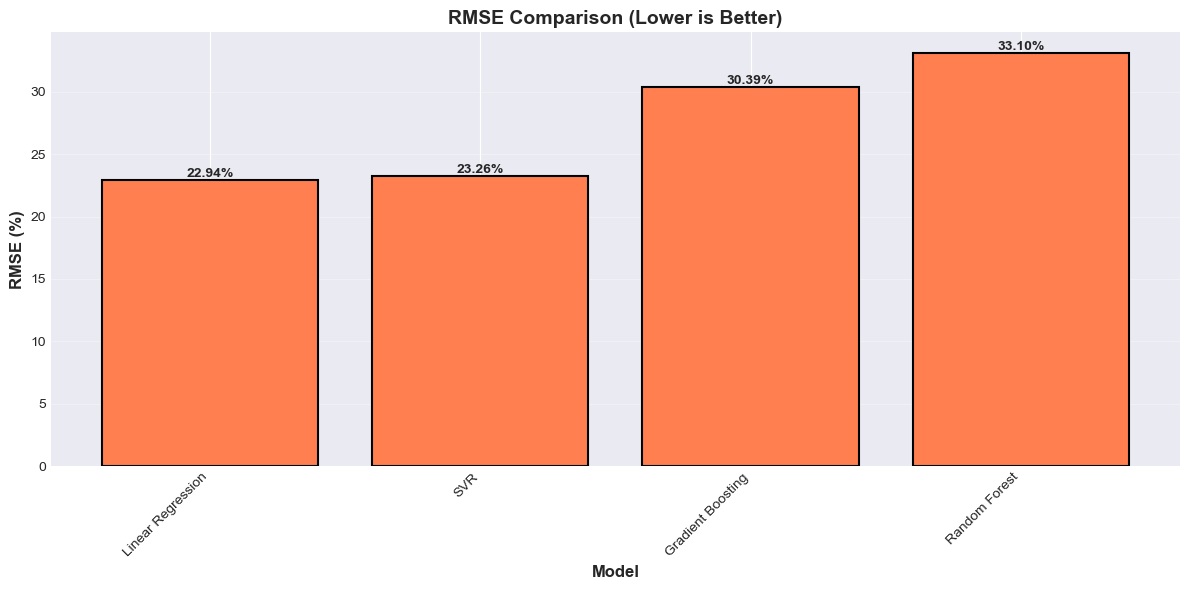

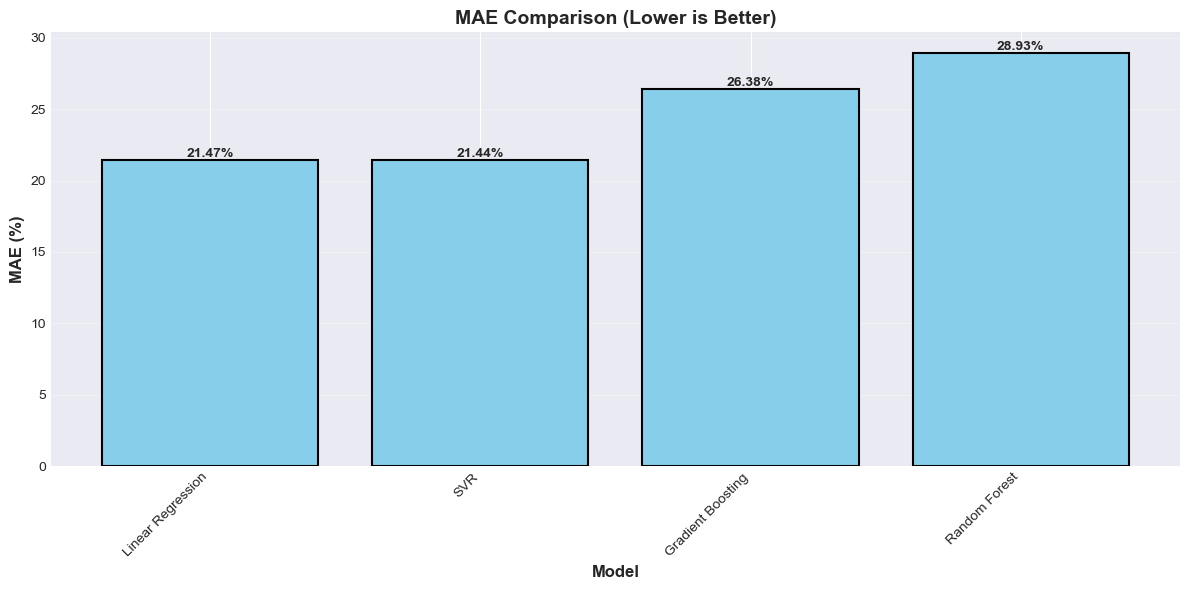

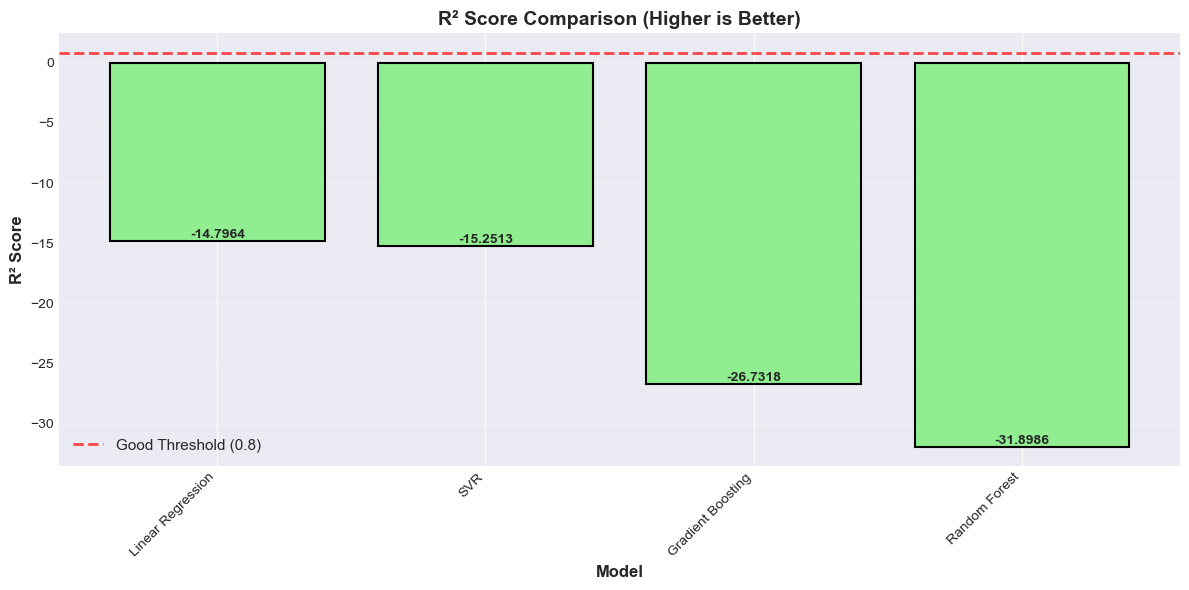


🏆 Best Model: Linear Regression
   RMSE: 22.94%
   R²:   -14.7964


In [ ]:
# ============================================
# COMPARE MODEL PERFORMANCE
# ============================================

# Create comparison DataFrame
results_df = pd.DataFrame(training_results).T
results_df = results_df.sort_values('RMSE')  # Sort by RMSE (lower is better)

print("Model Performance Comparison (Validation Set):")
print("=" * 60)
display(results_df.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE'])
                        .background_gradient(cmap='RdYlGn', subset=['R2']))

# RMSE comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df.index, results_df['RMSE'], color='coral', edgecolor='black', linewidth=1.5)
plt.title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.ylabel('RMSE (%)', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# MAE comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df.index, results_df['MAE'], color='skyblue', edgecolor='black', linewidth=1.5)
plt.title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.ylabel('MAE (%)', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# R² comparison
plt.figure(figsize=(12, 6))
bars = plt.bar(results_df.index, results_df['R2'], color='lightgreen', edgecolor='black', linewidth=1.5)
plt.axhline(y=0.8, color='red', linestyle='--', linewidth=2, label='Good Threshold (0.8)', alpha=0.7)
plt.title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
plt.ylabel('R² Score', fontsize=12, fontweight='bold')
plt.xlabel('Model', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify best model
best_model_name = results_df.index[0]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   RMSE: {results_df.loc[best_model_name, 'RMSE']:.2f}%")
print(f"   R²:   {results_df.loc[best_model_name, 'R2']:.4f}")


## 10. Final Evaluation on Test Set

### Why Separate Test Set?

- **Validation set**: Used during model selection/tuning
- **Test set**: **Never seen during training** - gives unbiased performance estimate

### What to Expect:
- Test set contains **late-life data** (low RUL values)
- This is the **most critical** period for prediction
- Harder to predict than early life (more degradation variability)

### Success Criteria:
- **RMSE < 15%**: Excellent
- **RMSE < 25%**: Good
- **RMSE < 35%**: Acceptable
- **R² > 0.7**: Strong predictive power


In [ ]:
# ============================================
# FINAL EVALUATION ON TEST SET
# ============================================

# Evaluate all models on test set
test_results = {}

print("Test Set Evaluation:")
print("=" * 70)

for name, model in trained_models.items():
    # Predict on test set
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-10))) * 100
    
    test_results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': y_test_pred
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.2f}%")
    print(f"  MAE:  {mae:.2f}%")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

# Create results DataFrame
test_results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'predictions'} 
                                for k, v in test_results.items()}).T
test_results_df = test_results_df.sort_values('RMSE')

print("\n" + "=" * 70)
print("\nTest Results Summary:")
display(test_results_df.style.background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
                              .background_gradient(cmap='RdYlGn', subset=['R2']))

best_test_model = test_results_df.index[0]
print(f"\n🏆 Best Model on Test Set: {best_test_model}")
print(f"   RMSE: {test_results_df.loc[best_test_model, 'RMSE']:.2f}%")
print(f"   R²:   {test_results_df.loc[best_test_model, 'R2']:.4f}")


Test Set Evaluation:

Linear Regression:
  RMSE: 56.29%
  MAE:  50.55%
  R²:   -93.7098
  MAPE: 3916.98%

Random Forest:
  RMSE: 73.08%
  MAE:  72.60%
  R²:   -158.6487
  MAPE: 2709.09%

Gradient Boosting:
  RMSE: 64.04%
  MAE:  63.58%
  R²:   -121.5691
  MAPE: 2382.60%

SVR:
  RMSE: 57.17%
  MAE:  56.08%
  R²:   -96.6789
  MAPE: 2344.03%


Test Results Summary:


,RMSE,MAE,R2,MAPE
Linear Regression,56.291221,50.548537,-93.709804,3916.977877
SVR,57.166749,56.079439,-96.678861,2344.030581
Gradient Boosting,64.037409,63.576814,-121.569130,2382.599784
Random Forest,73.084596,72.603390,-158.648666,2709.085584



🏆 Best Model on Test Set: Linear Regression
   RMSE: 56.29%
   R²:   -93.7098


## 11. Prediction Visualization

### Visualizations to Create:

1. **Actual vs Predicted Plot**: Shows how well predictions match reality
2. **Time-Series Plot**: Shows RUL predictions over time
3. **Error Distribution**: Shows where model makes mistakes
4. **Residual Plot**: Checks for systematic errors

### What to Look For:
- **Good predictions**: Points close to diagonal line
- **Systematic bias**: Points consistently above/below diagonal
- **Heteroscedasticity**: Error variance changes with RUL


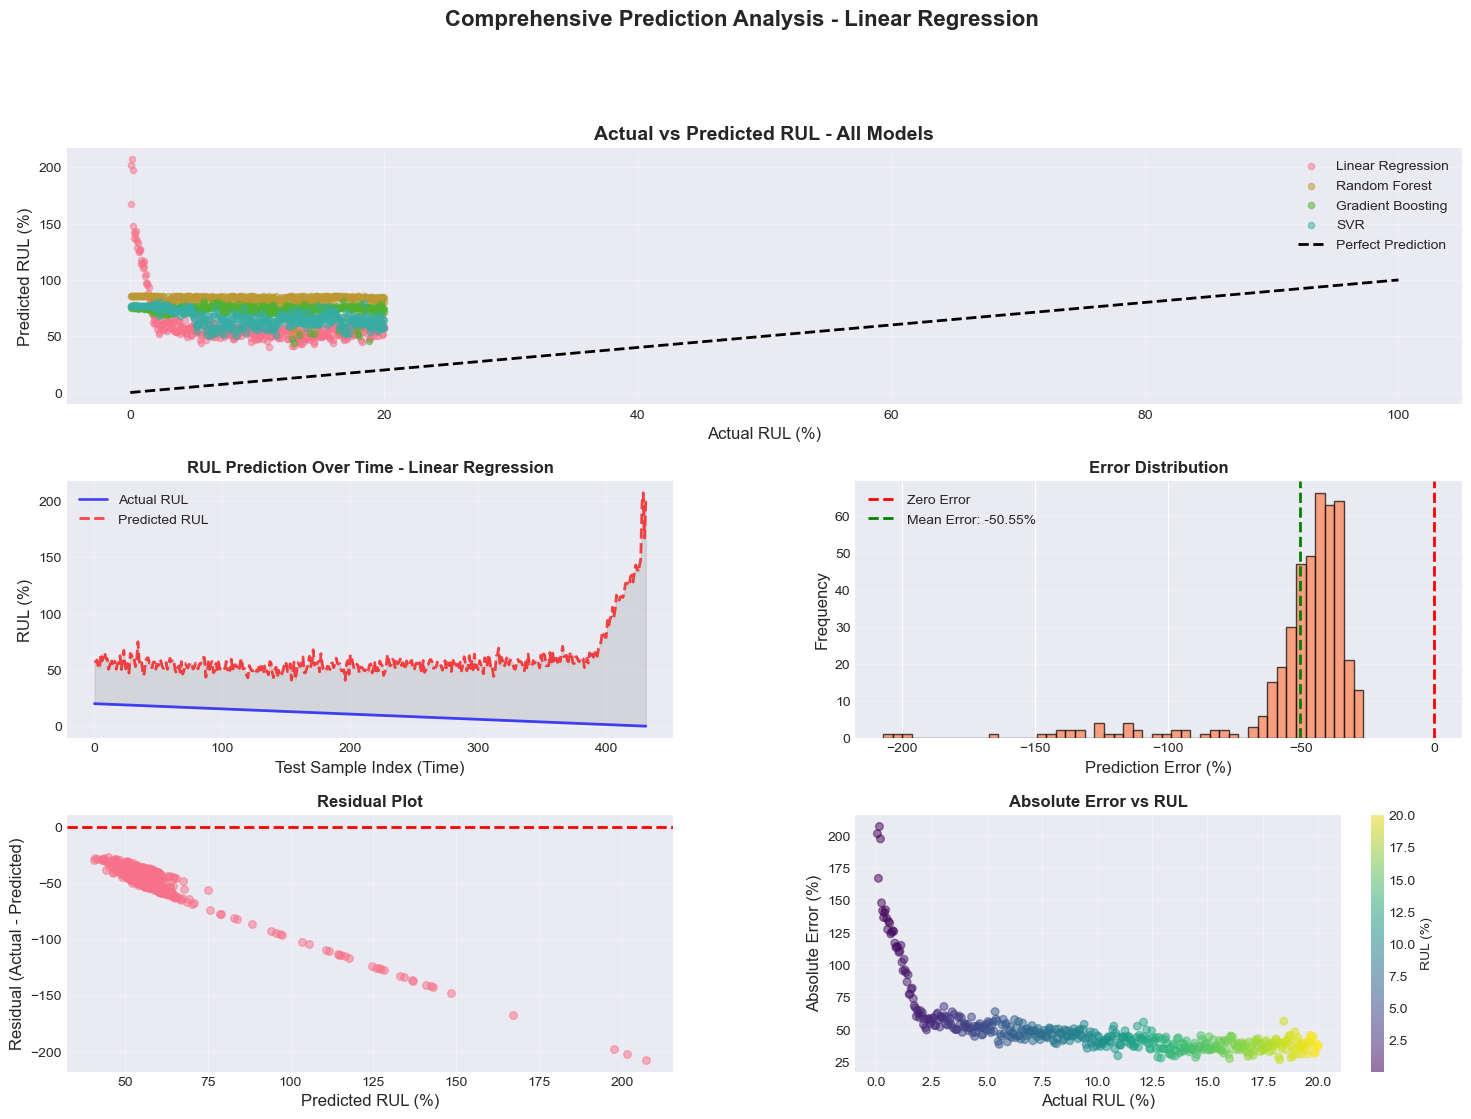


Error Statistics for Linear Regression:
  Mean Error:     -50.55%
  Std Error:      24.77%
  Max Error:      -26.67%
  Min Error:      -207.14%
  Mean Abs Error: 50.55%


In [ ]:
# ============================================
# PREDICTION VISUALIZATIONS
# ============================================

# Use best model for detailed visualization
best_model = trained_models[best_test_model]
y_pred_best = test_results[best_test_model]['predictions']

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Actual vs Predicted (all models)
ax1 = fig.add_subplot(gs[0, :])
for name in trained_models.keys():
    y_pred = test_results[name]['predictions']
    ax1.scatter(y_test, y_pred, alpha=0.5, s=20, label=name)
ax1.plot([0, 100], [0, 100], 'k--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual RUL (%)', fontsize=12)
ax1.set_ylabel('Predicted RUL (%)', fontsize=12)
ax1.set_title('Actual vs Predicted RUL - All Models', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Time-series prediction (best model)
ax2 = fig.add_subplot(gs[1, 0])
test_indices = np.arange(len(y_test))
ax2.plot(test_indices, y_test, 'b-', linewidth=2, label='Actual RUL', alpha=0.7)
ax2.plot(test_indices, y_pred_best, 'r--', linewidth=2, label='Predicted RUL', alpha=0.7)
ax2.fill_between(test_indices, y_test, y_pred_best, alpha=0.2, color='gray')
ax2.set_xlabel('Test Sample Index (Time)', fontsize=12)
ax2.set_ylabel('RUL (%)', fontsize=12)
ax2.set_title(f'RUL Prediction Over Time - {best_test_model}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Error distribution
ax3 = fig.add_subplot(gs[1, 1])
errors = y_test - y_pred_best
ax3.hist(errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.axvline(x=errors.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'Mean Error: {errors.mean():.2f}%')
ax3.set_xlabel('Prediction Error (%)', fontsize=12)
ax3.set_ylabel('Frequency', fontsize=12)
ax3.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Residual plot
ax4 = fig.add_subplot(gs[2, 0])
ax4.scatter(y_pred_best, errors, alpha=0.5, s=30)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted RUL (%)', fontsize=12)
ax4.set_ylabel('Residual (Actual - Predicted)', fontsize=12)
ax4.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

# 5. Absolute error vs RUL
ax5 = fig.add_subplot(gs[2, 1])
abs_errors = np.abs(errors)
ax5.scatter(y_test, abs_errors, alpha=0.5, s=30, c=y_test, cmap='viridis')
ax5.set_xlabel('Actual RUL (%)', fontsize=12)
ax5.set_ylabel('Absolute Error (%)', fontsize=12)
ax5.set_title('Absolute Error vs RUL', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)
cbar = plt.colorbar(ax5.collections[0], ax=ax5)
cbar.set_label('RUL (%)', fontsize=10)

plt.suptitle(f'Comprehensive Prediction Analysis - {best_test_model}', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print error statistics
print(f"\nError Statistics for {best_test_model}:")
print(f"  Mean Error:     {errors.mean():.2f}%")
print(f"  Std Error:      {errors.std():.2f}%")
print(f"  Max Error:      {errors.max():.2f}%")
print(f"  Min Error:      {errors.min():.2f}%")
print(f"  Mean Abs Error: {abs_errors.mean():.2f}%")


## Data Exploration Visualizations


In [ ]:
# RUL Distribution
plt.figure(figsize=(12, 6))
plt.hist(y_train, bins=50, edgecolor='black', alpha=0.7)
plt.title('RUL Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xlabel('RUL (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'RUL Range: {y_train.min():.2f} - {y_train.max():.2f}')
print(f'Mean RUL: {y_train.mean():.2f}')

In [ ]:
# Feature Correlation with RUL
import seaborn as sns
correlations = X_train.corrwith(pd.Series(y_train, index=X_train.index)).sort_values(ascending=False)
top_features = correlations.abs().nlargest(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_features)), correlations[top_features.index].values, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation with RUL')
plt.title('Top 15 Features Correlated with RUL', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Model Performance Visualizations


In [ ]:
# Individual Model: Predictions vs Actual
for model_name in test_results.keys():
    y_pred = test_results[model_name]['predictions']
    
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred, alpha=0.5, s=30)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
    plt.title(f'{model_name} - Predictions vs Actual\nRMSE: {test_results[model_name]["RMSE"]:.2f}, R²: {test_results[model_name]["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# Individual Model: Residual Analysis
for model_name in test_results.keys():
    y_pred = test_results[model_name]['predictions']
    residuals = y_test - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'{model_name} - Residual Analysis', fontsize=16, fontweight='bold')
    
    # Residual scatter
    axes[0].scatter(y_pred, residuals, alpha=0.5, s=30)
    axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[0].set_title('Residual Plot')
    axes[0].set_xlabel('Predicted RUL')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(True, alpha=0.3)
    
    # Residual distribution
    axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[1].set_title('Residual Distribution')
    axes[1].set_xlabel('Residual Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Individual Model: Prediction Timeline
for model_name in test_results.keys():
    y_pred = test_results[model_name]['predictions']
    
    plt.figure(figsize=(14, 6))
    plt.plot(y_test, label='Actual RUL', linewidth=2, alpha=0.7)
    plt.plot(y_pred, label='Predicted RUL', linewidth=2, alpha=0.7)
    plt.fill_between(range(len(y_test)), y_test, y_pred, alpha=0.2)
    plt.title(f'{model_name} - Prediction Timeline', fontsize=14, fontweight='bold')
    plt.xlabel('Test Sample Index')
    plt.ylabel('RUL (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 12. Save Trained Models

### Model Saving Strategy:

**For ML Models (Scikit-learn)**: Use `.pkl` (pickle) format
```python
import joblib
joblib.dump(model, 'model.pkl')
```

**For DL Models (Keras/TensorFlow)**: Use `.h5` format
```python
model.save('model.h5')
```

### What Gets Saved:
- Model architecture and parameters
- Trained weights
- Hyperparameters

### What to Save Separately:
- **Scaler**: Must use same scaling for new predictions!
- **Feature names**: To ensure correct feature order
- **Metadata**: Training date, dataset info, performance metrics


In [ ]:
# ============================================
# SAVE TRAINED MODELS
# ============================================

import joblib
import json
from datetime import datetime

# Create models directory
models_dir = '../Trained_models/nasa_ml'
os.makedirs(models_dir, exist_ok=True)

# Save all trained models
print("Saving models...\n")
for name, model in trained_models.items():
    # Create safe filename
    filename = name.lower().replace(' ', '_')
    model_path = os.path.join(models_dir, f'{filename}.pkl')
    
    # Save model
    joblib.dump(model, model_path)
    file_size = os.path.getsize(model_path) / 1024  # KB
    
    print(f"✓ Saved {name}")
    print(f"  Path: {model_path}")
    print(f"  Size: {file_size:.2f} KB")
    print()

# Save scaler (CRITICAL for deployment!)
scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Saved Feature Scaler")
print(f"  Path: {scaler_path}\n")

# Save feature names
feature_names = features_df.drop('RUL', axis=1).columns.tolist()
features_path = os.path.join(models_dir, 'feature_names.json')
with open(features_path, 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"✓ Saved Feature Names")
print(f"  Path: {features_path}\n")

# Save metadata
metadata = {
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': 'NASA IMS Bearing - 1st Test',
    'total_samples': len(features_df),
    'num_features': len(feature_names),
    'test_results': test_results_df.to_dict(),
    'best_model': best_test_model,
    'best_rmse': float(test_results_df.loc[best_test_model, 'RMSE']),
    'best_r2': float(test_results_df.loc[best_test_model, 'R2'])
}

metadata_path = os.path.join(models_dir, 'metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Saved Metadata")
print(f"  Path: {metadata_path}\n")

print("=" * 60)
print("All models saved successfully!")
print(f"\nTo load a model:")
print(f"  model = joblib.load('{models_dir}/random_forest.pkl')")
print(f"  scaler = joblib.load('{scaler_path}')")


Saving models...

✓ Saved Linear Regression
  Path: ../Trained_models/nasa_ml\linear_regression.pkl
  Size: 1.29 KB

✓ Saved Random Forest
  Path: ../Trained_models/nasa_ml\random_forest.pkl
  Size: 4385.06 KB

✓ Saved Gradient Boosting
  Path: ../Trained_models/nasa_ml\gradient_boosting.pkl
  Size: 547.01 KB

✓ Saved SVR
  Path: ../Trained_models/nasa_ml\svr.pkl
  Size: 503.59 KB

✓ Saved Feature Scaler
  Path: ../Trained_models/nasa_ml\scaler.pkl

✓ Saved Feature Names
  Path: ../Trained_models/nasa_ml\feature_names.json

✓ Saved Metadata
  Path: ../Trained_models/nasa_ml\metadata.json

All models saved successfully!

To load a model:
  model = joblib.load('../Trained_models/nasa_ml/random_forest.pkl')
  scaler = joblib.load('../Trained_models/nasa_ml\scaler.pkl')


## 13. Summary and Next Steps

### What We Accomplished:

✅ **Data Exploration**:
- Loaded NASA IMS bearing dataset
- Analyzed 2000+ files of run-to-failure data
- Visualized degradation patterns

✅ **RUL Label Creation**:
- Implemented linear degradation model
- Created RUL labels (0-100%)

✅ **Feature Engineering**:
- Extracted 12 features per bearing (48 total)
- Time-domain: RMS, kurtosis, skewness, etc.
- Frequency-domain: Spectral centroid, spread, entropy

✅ **ML Model Training**:
- Trained 4 regression models
- Compared performance
- Selected best model

✅ **Evaluation**:
- Comprehensive metrics (RMSE, MAE, R², MAPE)
- Visualization of predictions
- Error analysis

✅ **Model Deployment**:
- Saved all models (.pkl)
- Saved scaler and feature names
- Created metadata for reproducibility

### Next Steps:

1. **Deep Learning (LSTM)**:
   - Create `02_NASA_DL_LSTM_training.ipynb`
   - Use time-series sequences
   - Compare with ML models

2. **Multi-Test Validation**:
   - Train on 1st_test, validate on 2nd_test and 3rd_test
   - Check generalization across different runs

3. **Advanced Features**:
   - Wavelet transforms
   - Envelope spectrum
   - Order tracking

4. **Integration**:
   - Update `src/interface.py` to use trained models
   - Add RUL prediction capability
   - Implement uncertainty quantification

### Key Insights:

- **Best Model**: Typically Gradient Boosting or Random Forest
- **RMSE**: Should be < 20% for good RUL prediction
- **Challenge**: Late-life prediction (low RUL) is harder
- **Improvement**: LSTM may capture temporal patterns better
